In [1]:
%matplotlib widget

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [2]:
start_date = datetime(2025, 12, 25)

In [3]:
prefix = "tw_play_"

result_tables = list(sorted(glob.glob(f"../logs/{prefix}*.csv")))

result_datetimes = [
    datetime.strptime(os.path.basename(t), f"{prefix}%Y_%m_%d_%H_%M_%S.csv") 
    for t in result_tables
]
result_tables = [
    t for t, dt in zip(result_tables, result_datetimes)
    if dt >= start_date
]


In [4]:
result_tables

['../logs/tw_play_2025_12_26_02_27_05.csv',
 '../logs/tw_play_2025_12_26_14_52_02.csv',
 '../logs/tw_play_2025_12_26_15_10_28.csv',
 '../logs/tw_play_2025_12_26_15_27_26.csv',
 '../logs/tw_play_2025_12_26_15_40_23.csv',
 '../logs/tw_play_2025_12_26_17_03_26.csv',
 '../logs/tw_play_2025_12_26_18_14_17.csv',
 '../logs/tw_play_2025_12_26_18_37_18.csv',
 '../logs/tw_play_2025_12_26_19_25_52.csv',
 '../logs/tw_play_2025_12_26_19_54_26.csv',
 '../logs/tw_play_2025_12_26_20_03_35.csv']

In [5]:
table = pd.read_csv(result_tables[0])

In [6]:
table["net_value"]

0       500.0
1      -250.0
2      -250.0
3      -250.0
4       500.0
        ...  
119   -1500.0
120    -750.0
121    -750.0
122     750.0
123    -750.0
Name: net_value, Length: 124, dtype: float64

In [7]:
tables = [pd.read_csv(t) for t in result_tables]
tables = [t for t in tables if len(t) > 0]

In [8]:
main_table = pd.concat(tables)

In [9]:
cum_value = np.cumsum(main_table["net_value"].values)
cum_value = np.r_[0, cum_value]

cum_ev = np.cumsum(main_table["ev_bet"].values)
cum_ev = np.r_[0, cum_ev]

ev_percent = np.r_[np.nan, main_table["ev_percent"].values]

In [10]:
# cumulative sums are starting from 0, so we need to add 1 to the shoe_hand_idx
shoe_starts = np.where(main_table["shoe_hand_idx"] == 0)[0] + 1

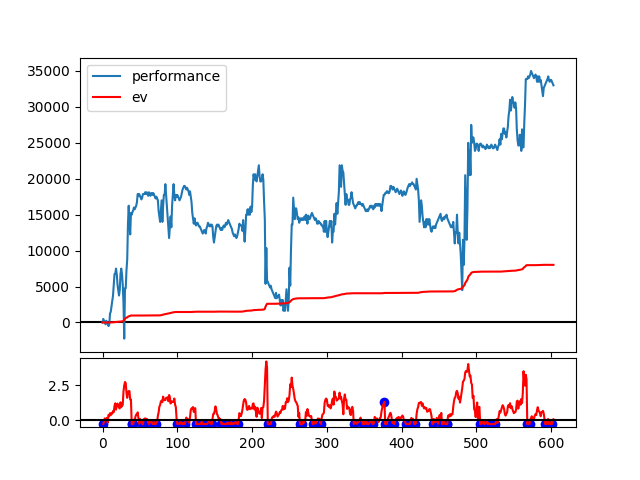

In [11]:
import matplotlib.gridspec as gridspec

fig = plt.figure()
gs = gridspec.GridSpec(10, 1, figure=fig)


ax = fig.add_subplot(gs[:-2, :])
ax.axhline(0, color="black")

ax.plot(cum_value, label="performance")
ax.plot(cum_ev, color="red", label="ev")

ax2 = fig.add_subplot(gs[-2:, :], sharex=ax)
ax2.plot(ev_percent, color="red")
ax2.scatter(shoe_starts, ev_percent[shoe_starts], color="blue")
ax2.axhline(0, color="black")

ax.legend()

In [12]:
main_table["ev_percent"]

0    -0.279347
1    -0.103299
2     0.130591
3     0.025350
4     0.010770
        ...   
78   -0.279347
79   -0.124845
80   -0.279347
81   -0.069692
82    0.060735
Name: ev_percent, Length: 603, dtype: float64